In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
conn=sqlite3.connect(":memory:")
cursor = conn.cursor()

# Create a sample sales table
cursor.execute('''
CREATE TABLE online_sales (
    order_id TEXT,
    product TEXT,
    quantity INTEGER,
    unit_price REAL
);
''')

# Insert sample data
sample_data = [
    ('ORD001', 'Apple', 2, 100000),
    ('ORD002', 'Samsung', 5, 50000),
    ('ORD003', 'Oneplus', 10, 90000),
    ('ORD004', 'Mottorola', 3, 30000),
    ('ORD005', 'Redmi', 3, 40000),
    ('ORD006', 'Vivo', 3, 60000)
]

cursor.executemany('INSERT INTO online_sales VALUES (?, ?, ?, ?)', sample_data)
conn.commit()

In [5]:
df = pd.read_sql_query('''
    SELECT 
        product, 
        SUM(quantity) AS total_quantity,
        SUM(quantity * unit_price) AS total_revenue
    FROM online_sales
    GROUP BY product
''', conn)


print(df)

     product  total_quantity  total_revenue
0      Apple               2       200000.0
1  Mottorola               3        90000.0
2    Oneplus              10       900000.0
3      Redmi               3       120000.0
4    Samsung               5       250000.0
5       Vivo               3       180000.0


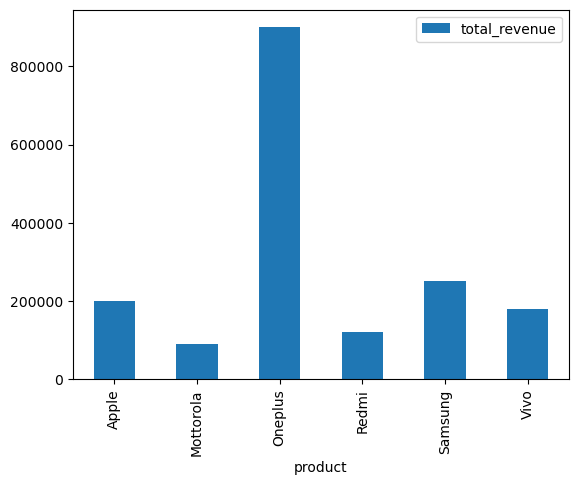

In [7]:
df.plot(kind='bar', x='product', y='total_revenue')
plt.show()

In [8]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>